In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [32]:
pd.set_option('display.precision',6)
data_url = 'https://raw.githubusercontent.com/codingalzi/code-workout-datasci/refs/heads/master/data/'

In [33]:
wine_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
wine_df = pd.read_csv(wine_url, sep=";")
#다중 클래스 분류는 하지 않고
#quality를 7이상 good 아니면 Ordinary로 설정해
#이진분류로 진행하도록 한다.

In [34]:
#로지스틱 회귀는 모델 명에 회귀가 들어가서
#회귀 모델이라 착각할 수 있으나
#분류 모델임에 유의해야한다.

In [35]:
wine_df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [36]:
wine_df.shape

(1599, 12)

In [37]:
wine_df.info()
#float64는 수치형 특성
#int64는 수치형 특성이기도 범주형 특성이기도 하다
#어떻게 보느냐에 따라서 달라진다.

<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [38]:
wine_df.select_dtypes(include="float").describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000


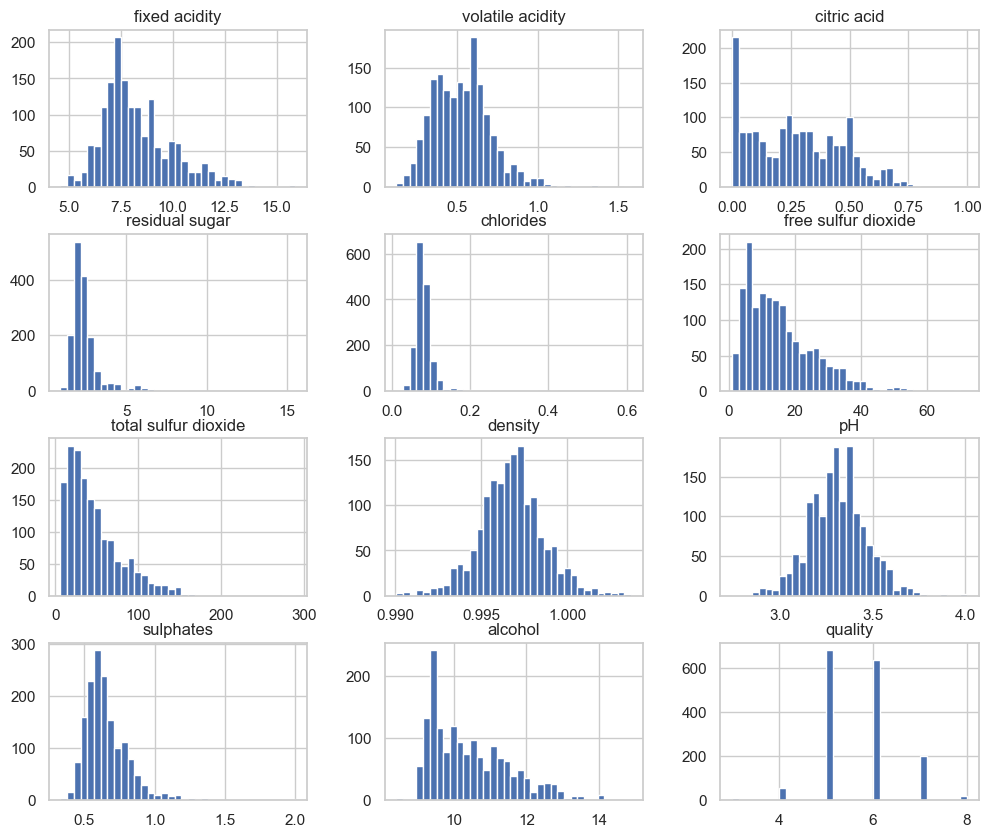

In [39]:
wine_df.hist(bins=35, figsize=(12,10))
plt.show()

In [ ]:
#위에 없앤건 코드 실행 제대로 안되기 때문
#재 작성 요망
# 23.8 전처리 파이프라인

#모델이 일을 쉽게하도록 도와
#내가 뭔가 일을 해야해, 요리같은?
#식재료를 사왔어, 씻어서 먹고, 썰고, 조리를 해야하잖아
#그게 바로 전처리야

#근데 머신러닝 모델은 직접 전처리 못해
#그래서 인간이 잘 해줘야해?

#상용적으로만 얘기하고 넘길거고

#표준화는 정규분포 못만들고
#log분포 사용하면 밀집된 애들 조금 완화되거나


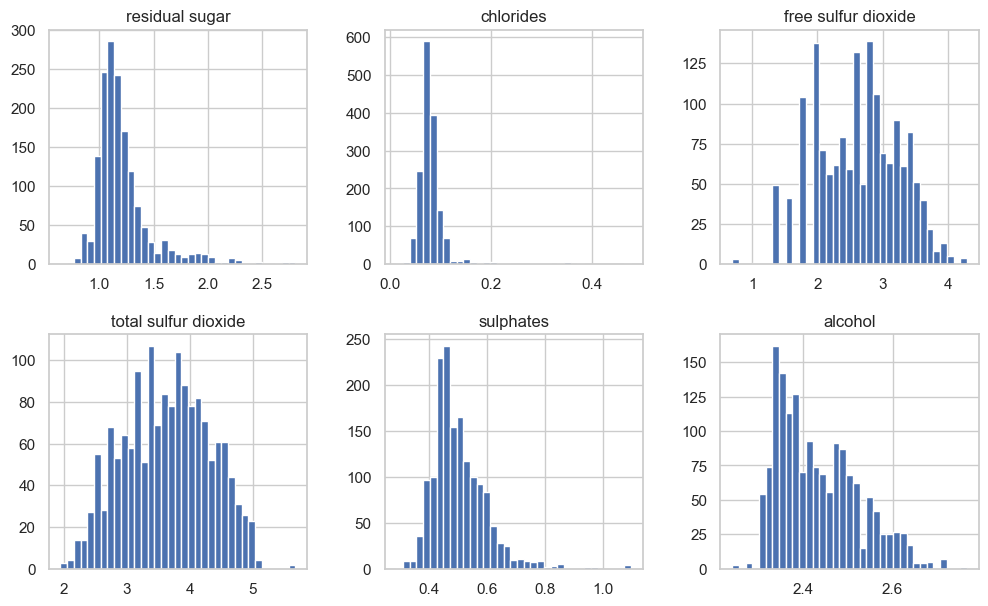

In [48]:
log_features=[
    "residual sugar",
    "chlorides",
    "free sulfur dioxide",
    "total sulfur dioxide",
    "sulphates",
    "alcohol"
]

wine_log=np.log1p(wine_df[log_features])

wine_log.hist(bins=35, figsize=(12,7), layout=(2,3))
plt.show()

In [ ]:
#long_pipline은 변환기
#make_pipeline은 sklearn
#6개 특성 로그 변환, 표준화 하겠다

#ColumnTransformer 병렬처리해
#열(특성)별로 변환기를 따로 적용
#preprocessor는 전처리 변환기야
#"log",는 별로 중요하지 않아
#나머지 애들 표준화 할거야

#변환기 지정만하고 아직은 뭘 안한놈

In [ ]:
#전처리 변환기랑 예측 모델이랑 합쳐서
#동시에 훈련을 시킬거야
#먼저 얘가 변환기 통과해 예측모델 하용

#로지스틱이랑 랜덤 포레스트
#나랑 페라리 탈래 모닝 탈래
#나랑 벤틀리 탈래 캐스퍼 탈래!
#나랑 람보르기니 탈래 레이 탈래!!!!

#저는 돈 없어서 레이 모닝 캐스퍼요

#결론 : 적은 비용으로 효율 좋은 모델

In [ ]:
#logistic_pipline은 전처리 + 예측기를 담았어
#넌 만능 병사다
#가서 취사병이나해!

#preprocessor가 X_train 짬처리
#짬처리한거 LogisticRegression() 냠냠

#이전에는 혼자 수저로 밥도 못퍼먹어
#하지만 얘는 수저로 산을 옮긴다

#표준화 신경 안써안써룬

In [ ]:
#RandomForest는 전처리 필요 노노
#n_estimators=300 이거 없어도 되는거야
#전처리 없이 바로 훈련을 하면 되는
#열정페이 스폰지밥

In [ ]:
#모델 정확도 평가
#확률로 하면 너무너무 애매해
#0.4999999999999999랑 0.49999999999998
#뭐가 더 좋은거고 안좋은걸까?
#이게 말이야 방구야 도긴개긴이야

#따라서 맞추는 갯수로 정확도를 따지는거

#근데 여기서 Ordinary에 7-80 비중

#정확도가 88이여도 낮다고 볼 수 있음
#그리 좋은 모델이 아니야

#결론 : 이미 출발선이 다른데
#노력해서 조금 높다고 좋은건 아니지

In [ ]:
#277
#43

#다 Ordinary로 찍어도 0.865625

#혼동행렬
#TN : FP
#FN : TP
#참음성 : 거짓양성
#거짓음성 : 참양성

#Ordinary 예측 맞춘 개수 : Ordinary 예측 틀린 개수
#Good 예측 틀린 개수 : Good 예측 맞춘 개수

#43개 중 12개 맞춘거 재현율 0.3에 근사
#0.279069767
#recall이라고 부르고 good을 잘 맞춰야
#좋은 애인건데 싹다 틀리면 널 왜 써

#정밀도는 FP/TP로 구하고
#현재 결과에서는 12/17, 0.70
#별로 좋은거 아님
#good 맞춘거 개수 너무 적어

#난 단지 일머리 있고, 예의바르고, 똑부러진 후임을 원했는데 왜 없는거야
#재현율도 좋고 정밀도도 좋은 모델 원해

In [ ]:
#랜덤포레스트 변수 중요도 구해
#11개의 특성값으로 Good, Ordinary 파악, 그 중 뭐가 중요한지 알아내
#수치화시켜서 계산을 하는데 얘기안해

#랜포가 알코올
#진짜암인데 암이 아니다!(재현율낮음)
#이럼 큰일나
#가짜암인데 암이 맞다! (정밀도 낮음)
#이건 안죽잖아

<Axes: xlabel='alcohol', ylabel='residual sugar'>

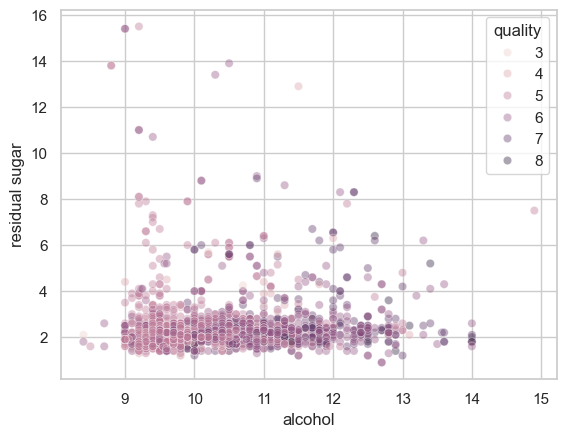

In [41]:
sns.scatterplot(data=wine_df, x="alcohol",y="residual sugar", hue="quality", alpha=0.4)

c:\Users\skato\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


Text(0.5, 1.0, 'Residual Sugar by Alchol')

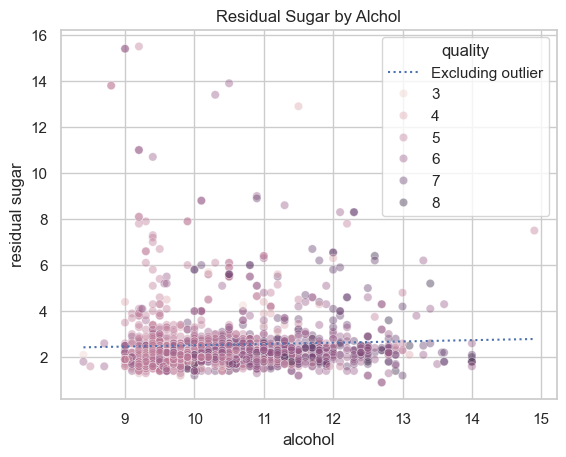

In [42]:
X=wine_df[["alcohol"]]
y=wine_df["residual sugar"]
from sklearn.linear_model import LinearRegression
model = LinearRegression() #기존 데이터 선형회귀
model.fit(X, y)

X_min = wine_df["alcohol"].min()
X_max = wine_df["alcohol"].max()

X_range = np.linspace(X_min, X_max, 200).reshape(-1,1)

#예측값 저장
y_full = model.predict(X_range)

plt.plot(X_range, y_full, "b:", label="Excluding outlier")

sns.scatterplot(data=wine_df, x="alcohol",y="residual sugar", hue="quality", alpha=0.4)

plt.title("Residual Sugar by Alchol")


In [43]:
wine_df["quality_label"] = (wine_df["quality"] >= 7).map({True: "good", False: "ordinary"})

c:\Users\skato\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


Text(0.5, 1.0, 'Residual Sugar by Alchol')

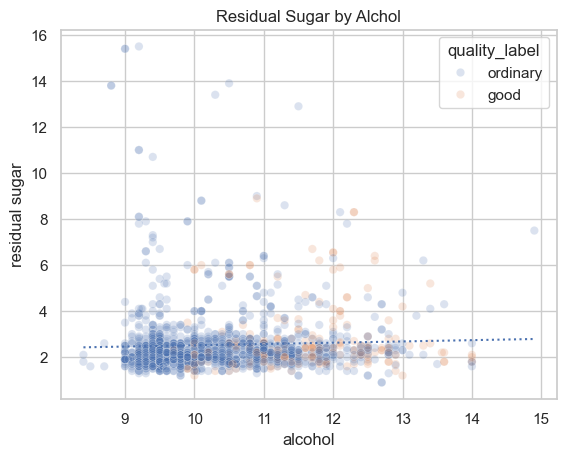

In [44]:
X=wine_df[["alcohol"]]
y=wine_df["residual sugar"]
from sklearn.linear_model import LinearRegression
model = LinearRegression() #기존 데이터 선형회귀
model.fit(X, y)

X_min = wine_df["alcohol"].min()
X_max = wine_df["alcohol"].max()

X_range = np.linspace(X_min, X_max, 200).reshape(-1,1)

#예측값 저장
y_full = model.predict(X_range)

plt.plot(X_range, y_full, "b:")

sns.scatterplot(data=wine_df, x="alcohol",y="residual sugar", hue="quality_label", alpha=0.2)

plt.title("Residual Sugar by Alchol")


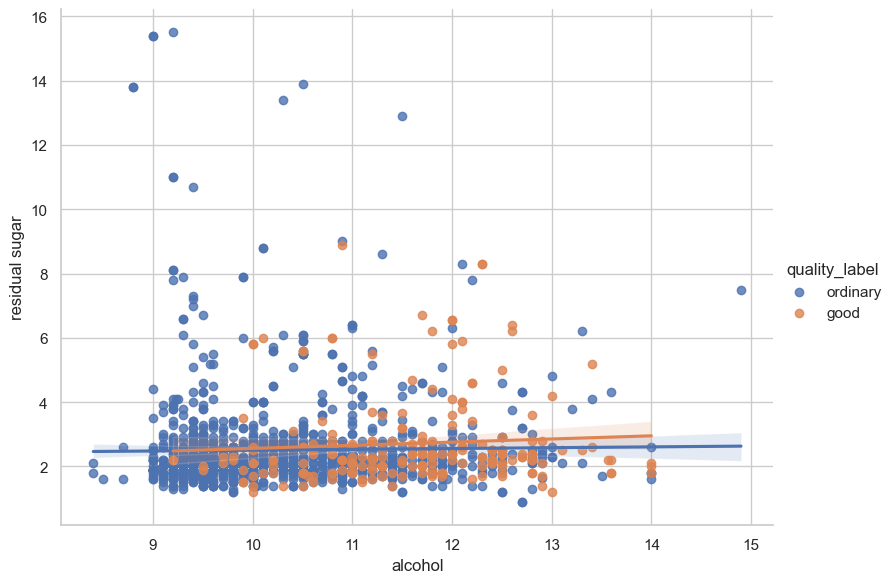

In [45]:
sns.lmplot(data=wine_df, x='alcohol', y='residual sugar', hue='quality_label', height=6, aspect=8/6)
plt.show()

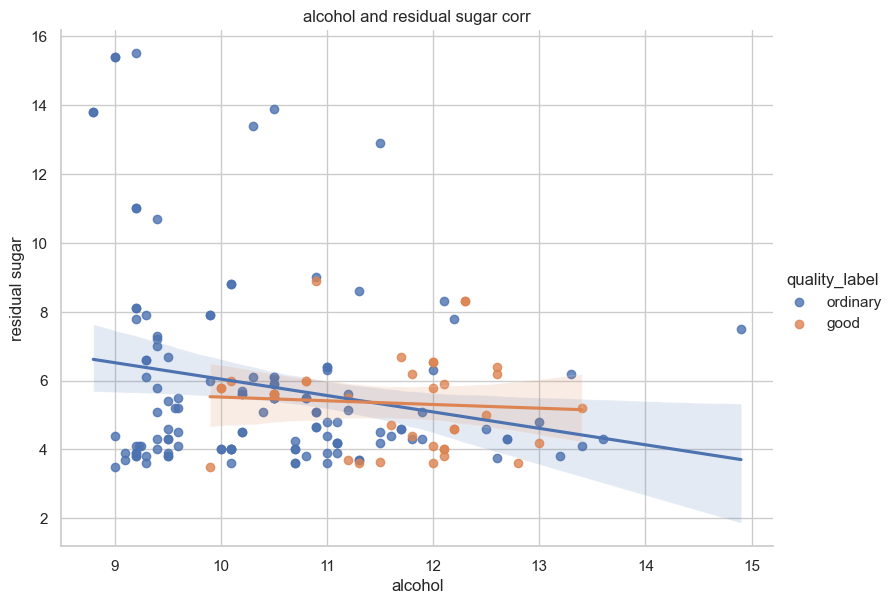

In [46]:
filtered_df = wine_df.loc[wine_df["residual sugar"] >= 3.5]
sns.lmplot(data=filtered_df, x='alcohol', y='residual sugar', hue='quality_label', height=6, aspect=8/6)
plt.title("alcohol and residual sugar corr")
plt.show()

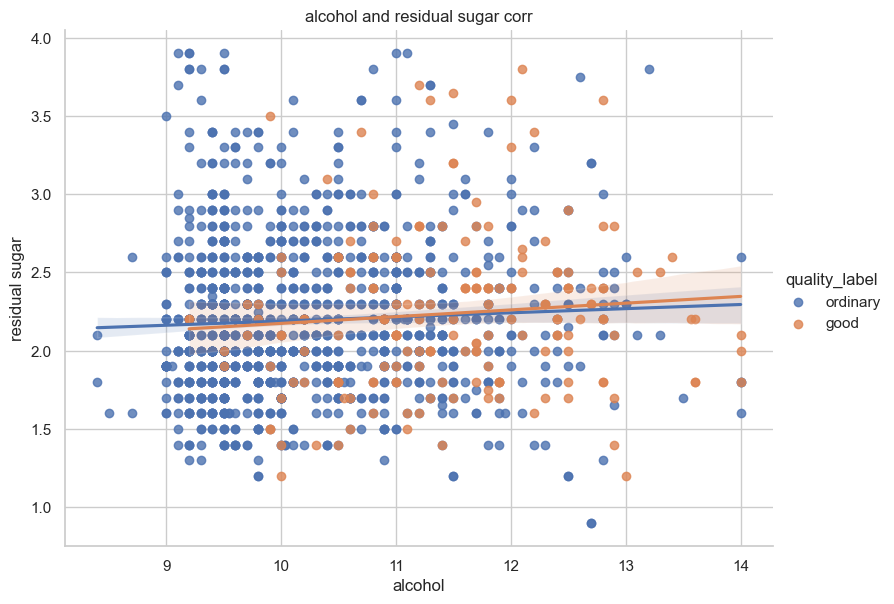

In [47]:
filtered_df = wine_df.loc[wine_df["residual sugar"] < 4]
sns.lmplot(data=filtered_df, x='alcohol', y='residual sugar', hue='quality_label', height=6, aspect=8/6)
plt.title("alcohol and residual sugar corr")
plt.show()